### 2027. 07. 27. 공유자전거 대여 운영 데이터 전처리와 EDA

- 원본 파일 : A_공유자전거_대여운영_dirty.csv
- 작업 파일 : A_공유자전거_분석_홍은경.ipynb
- 결과 파일 : A_공유자전거_cleaned.csv

# Part 1. 분석 데이터 전처리

## 문제 1. 데이터 구조와 품질 문제 확인
- 1. 데이터를 불러와 `head()`, `shape`, `info()`, `describe(include="all")`를 확인하세요.
- 2. 각 컬럼의 결측치 개수와 결측 비율을 표로 만드세요.
- 3. `duplicated()`를 이용해 완전히 중복된 행의 개수를 확인하세요.
- 4. `duplicated(subset=["rental_id"])`로 `rental_id` 기준 중복 개수도 확인하고, 3번 결과와 다르다면 그 이유를 설명하세요.
- 5. `rental_id`가 분석용 피처인지 식별자인지 판단하고 근거를 1문장으로 작성하세요.

In [663]:
# 라이브러리 불러오기 및 한글 폰트 설정
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# 한글 폰트 설정
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### 1. 데이터 불러오기, `head()`, `shape`, `info()`, `describe(include="all")`를 확인

In [664]:
# 데이터 불러오기

df = pd.read_csv('A_공유자전거_대여운영_dirty.csv')
df.head()

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


In [665]:
df.shape

(652, 11)

In [666]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 56.2 KB


In [667]:
# describe()만 쓰면 수치형 컬럼의 평균/표준편차/최솟값/최댓값 등만 보여줌.
# include="all"을 추가하면 문자열(범주형) 컬럼의 통계(고유값 개수, 최빈값 등)까지 같이 보여줌.
df.describe(include = 'all')

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


### 2. 각 컬럼의 결측치 개수와 결측 비율을 표로 만들기

In [668]:
# 결측치 확인하기
df.isnull().sum()

rental_id             0
station_zone          0
member_type          23
weather              17
temperature_c         0
humidity_pct         25
wind_speed_mps        0
distance_km           0
ride_duration_min    21
bike_age_months      14
late_return           0
dtype: int64

In [669]:
missing_ratio = df.isnull().mean()
missing_ratio

rental_id            0.000000
station_zone         0.000000
member_type          0.035276
weather              0.026074
temperature_c        0.000000
humidity_pct         0.038344
wind_speed_mps       0.000000
distance_km          0.000000
ride_duration_min    0.032209
bike_age_months      0.021472
late_return          0.000000
dtype: float64

In [670]:
# 결측치 컬럼을 추출하여 리스트로 저장. 
# missing_ratio[missing_ratio > 0] --> Series(컬럼명 + 결측비율) 가 저장
# missing_ratio[missing_ratio > 0].index --> 컬럼 이름만 필요
# missing_ratio[missing_ratio > 0].index.tolist() --> 리스트로 변환
drop_cols = missing_ratio[missing_ratio > 0].index.tolist()
drop_cols

['member_type',
 'weather',
 'humidity_pct',
 'ride_duration_min',
 'bike_age_months']

In [671]:
missing_df =pd.DataFrame({
    '결측치 개수': df.isnull().sum(),
    '결측 비율' : (df.isnull().mean() * 100).round(2)})
missing_df

,결측치 개수,결측 비율
rental_id,0,0.00
station_zone,0,0.00
member_type,23,3.53
weather,17,2.61
temperature_c,0,0.00
humidity_pct,25,3.83
wind_speed_mps,0,0.00
distance_km,0,0.00
ride_duration_min,21,3.22
bike_age_months,14,2.15


### 3. duplicated()를 이용해 완전히 중복된 행의 개수를 확인하기

In [672]:
# 모든 컬럼의 값이 완전히 같은 행만 중복으로 판단
df_dup = df[df.duplicated()]
df_dup


,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
644,R0019,주거,일일권,맑음,29.5,45.3,2.4,58.81,11.0,28.0,1
645,R0078,도심,일일권,흐림,29.9,66.5,0.2,4.49,29.9,31.0,0
646,R0212,도심,연회원,맑음,20.1,47.2,3.4,2.07,11.5,19.0,0
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0


In [673]:
df.duplicated().sum()

np.int64(6)

### 4. duplicated(subset=["rental_id"])로 rental_id 기준 중복 개수도 확인하고, 3번 결과와 다르다면 그 이유를 설명하기

In [674]:
# rental_id 컬럼만 비교하여 중복 여부를 판단
df[df.duplicated(subset=['rental_id'])]

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
644,R0019,주거,일일권,맑음,29.5,45.3,2.4,58.81,11.0,28.0,1
645,R0078,도심,일일권,흐림,29.9,66.5,0.2,4.49,29.9,31.0,0
646,R0212,도심,연회원,맑음,20.1,47.2,3.4,2.07,11.5,19.0,0
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0
651,R0137,주거,일일권,비,19.8,73.8,3.7,4.13,27.0,16.0,0


In [675]:
df['rental_id'].duplicated().sum()

np.int64(8)

### 5. rental_id가 분석용 피처인지 식별자인지 판단하고 근거를 1문장으로 작성하기

- rental_id는 각 대여 기록을 고유하게 식별하는 값으로, 분석에 활용되는 특성(feature)이 아니라 식별자(ID)이다

## 문제 2. 중복과 결측치 처리

- 1. 완전히 중복된 행을 제거하고 제거 전후 행 수를 출력하세요.
- 2. `rental_id` 기준으로는 중복이지만 완전 중복은 아닌 행이 있다면, 어느 행을 남길지(예: 최신 값 우선, 평균 등) 기준을 정하고 처리하세요.
- 3. 수치형 결측치와 범주형 결측치를 구분하세요.
- 4. 다음 조건을 만족하도록 결측치를 처리하세요.
    - 범주형 컬럼: 최빈값 또는 `"미상"` 중 하나를 선택
    - 수치형 컬럼: 평균, 중앙값, 그룹별 중앙값 중 하나를 선택
- 5. 각 처리 방법을 선택한 이유를 컬럼별로 간단히 설명하세요.
- 6. 처리 후 결측치가 남아 있지 않은지 검증하세요.

> 단순히 코드를 실행하는 것보다 “왜 이 대표값을 사용했는가”를 설명하는 것이 중요합니다.

In [676]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


### 1. 완전히 중복된 행을 제거하고 제거 전후 행 수를 출력하기

In [677]:
# .copy()를 붙이는 이유: 안 붙이면 pandas가 "원본의 일부를 보고 있는 상태(view)"로 취급해서, 나중에 dedup을 수정할 때 경고가 뜨거나 예상 못한 동작이 생길 수 있습니다. 
# .copy()로 완전히 별개의 데이터프레임을 만들어 안전하게 작업합니다.

df_dup = df.drop_duplicates().copy()
df_dup

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
641,R0642,대학가,연회원,흐림,22.4,80.8,5.5,1.53,8.6,NaN,0
642,R0643,주거,월회원,맑음,31.6,64.0,3.4,3.08,17.9,27.0,0
643,R0644,대학가,일일권,맑음,20.3,56.5,3.3,4.05,23.7,1.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


In [678]:
print(f'제거 전 행 수: {len(df)}')
print(f'제거 후 행 수: {len(df_dup)}')
print(f'제거된 중복 행 수: {len(df) - len(df_dup)}')

제거 전 행 수: 652
제거 후 행 수: 646
제거된 중복 행 수: 6


### 2. `rental_id` 기준으로는 중복이지만 완전 중복은 아닌 행이 있다면, 어느 행을 남길지(예: 최신 값 우선, 평균 등) 기준을 정하고 처리하기

In [679]:
# rental_id가 수치형 데이터가 아니므로 평균을 적용할수 없다.
# rental_id는 각 대여를 고유하게 식별하는 값이므로, 동일한 rental_id가 여러 번 존재하는 경우 첫 번째 기록을 유지하고 나머지 중복 행은 제거하기로 정함.
df_dup = df.drop_duplicates(subset=['rental_id'], keep='first')

print(f'중복 제거 후 행 수: {len(df_dup)}')

중복 제거 후 행 수: 644


In [680]:
df_dup

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
639,R0640,주거,월회원,비,30.6,77.7,4.8,1.52,NaN,1.0,0
640,R0641,대학가,일일권,비,25.8,69.4,4.6,6.19,35.4,23.0,0
641,R0642,대학가,연회원,흐림,22.4,80.8,5.5,1.53,8.6,NaN,0
642,R0643,주거,월회원,맑음,31.6,64.0,3.4,3.08,17.9,27.0,0


### 3. 수치형 결측치와 범주형 결측치를 구분하기

In [681]:
# 수치형 결측치 구분하기
num_cols_na = df_dup.select_dtypes(include='number').columns
num_cols_na = num_cols_na[df_dup[num_cols_na].isnull().any()]
num_cols_na

Index(['humidity_pct', 'ride_duration_min', 'bike_age_months'], dtype='str')

In [682]:
# 범주형 결측치 구분하기
cat_cols_na = df_dup.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols_na[df_dup[cat_cols_na].isnull().any()]
cat_cols_na

Index(['member_type', 'weather'], dtype='str')

### 4. 다음 조건을 만족하도록 결측치를 처리하세요.
    - 범주형 컬럼: 최빈값 또는 `"미상"` 중 하나를 선택
    - 수치형 컬럼: 평균, 중앙값, 그룹별 중앙값 중 하나를 선택


In [683]:
df_dup.isnull().sum()

rental_id             0
station_zone          0
member_type          22
weather              17
temperature_c         0
humidity_pct         25
wind_speed_mps        0
distance_km           0
ride_duration_min    21
bike_age_months      14
late_return           0
dtype: int64

In [684]:
# 수치형 결측치를 중앙값으로 채우기
for n in num_cols_na: 
    df_dup[n] =df_dup[n].fillna(df_dup[n].median())

df_dup.isnull().sum()

rental_id             0
station_zone          0
member_type          22
weather              17
temperature_c         0
humidity_pct          0
wind_speed_mps        0
distance_km           0
ride_duration_min     0
bike_age_months       0
late_return           0
dtype: int64

In [685]:
# 범주형 결측치('member_type')를 최빈값으로 채우기
df_dup['member_type'] = df_dup['member_type'].fillna(df_dup['member_type'].mode()[0])

df_dup.isnull().sum()

rental_id             0
station_zone          0
member_type           0
weather              17
temperature_c         0
humidity_pct          0
wind_speed_mps        0
distance_km           0
ride_duration_min     0
bike_age_months       0
late_return           0
dtype: int64

In [686]:
# 범주형 결측치('weather')를 최빈값으로 채우기
df_dup['weather'] = df_dup['weather'].fillna(df_dup['weather'].mode()[0])

df_dup.isnull().sum()

rental_id            0
station_zone         0
member_type          0
weather              0
temperature_c        0
humidity_pct         0
wind_speed_mps       0
distance_km          0
ride_duration_min    0
bike_age_months      0
late_return          0
dtype: int64

### 5. 각 처리 방법을 선택한 이유를 컬럼별로 간단히 설명하세요.

- 수치형 결측치의 경우 평균값으로 채우면, 이상치의 영향을 받아 결과에 오류가 발생할 수 있어, 중간값으로 선택함..
- 범주형 결측치의 경우 빈도수가 높은 것이 결과에 영향을 덜 미칠것 같아서 선택함.

## 문제 3. 이상치 탐지와 처리 전략

- 1. `temperature_c`, `humidity_pct`, `distance_km`, `ride_duration_min`의 boxplot을 그리세요.
- 2. 각 컬럼에 대해 IQR 하한·상한과 이상치 개수를 계산하세요.
- 3. 다음 두 종류를 구분하세요.
    - 통계적으로 드물지만 실제로 가능할 수 있는 값
    - 습도 100% 초과처럼 도메인 규칙을 위반한 값
- 4. 아래 처리 방법 중 컬럼별로 적절한 방법을 선택하고 이유를 적으세요.
    - 행 제거
    - IQR 경계값으로 capping
    - 현실 범위 경계값으로 보정
    - 원본 값 유지 + 이상치 여부 플래그 생성
- 5. 처리 전후의 boxplot 또는 요약 통계를 비교하세요.

In [687]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


<Axes: >

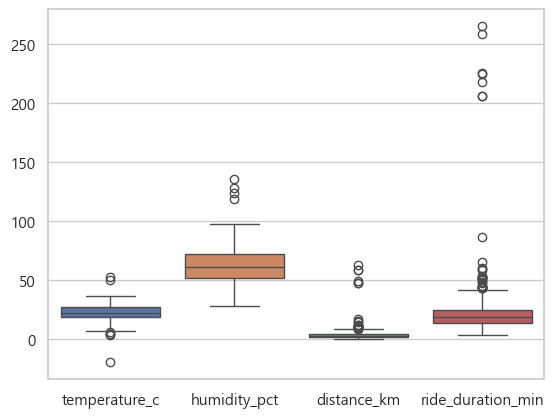

In [688]:
outlier_cols = ["temperature_c", "humidity_pct", "distance_km", "ride_duration_min"]

sns.boxplot(data=df[outlier_cols])

### temperature_c의 boxplot, IQR, 이상치 개수 구하기

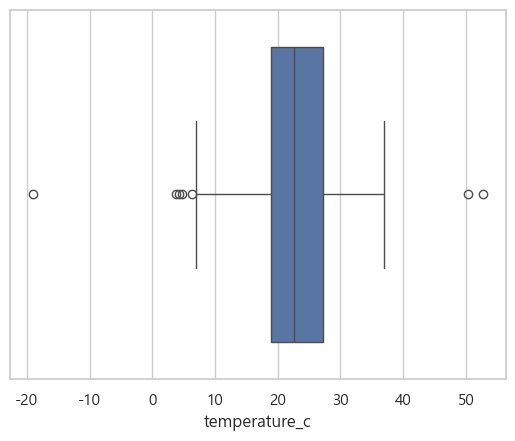

In [689]:
# temperature_c의  boxplot
sns.boxplot(x=df['temperature_c'])
plt.show()

In [690]:
# Q1(1사분위수) 25%
q1 = df['temperature_c'].quantile(.25)

# Q3(3사분위수) 75%
q3 = df['temperature_c'].quantile(.75)

q1, q3

(np.float64(19.0), np.float64(27.225))

In [691]:
# IQR 구하기
iqr = q3 -q1
iqr

np.float64(8.225000000000001)

In [692]:
# 이상치 범위 구하기
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
lower, upper

(np.float64(6.662499999999998), np.float64(39.5625))

In [693]:
n_outlier = ((df['temperature_c'] < lower) | (df['temperature_c'] > upper)).sum()
n_outlier

np.int64(7)

### 결측치 처리 - capping

In [694]:
# 우리나라를 기준으로 잡았을 경우 결측치의 값은 나오기가 힘든 온도이다. 
# 그러나 가끔 기상이변으로 인해 나타날 수도 있고, 표본 수가 적을수록 뒤쪽 EDA(그룹 비교)에서 신뢰도가 떨어지므 표본을 유지하면서 극단값만 완화하는 capping을 선택함.
# .clip() -> 값의 범위를 강제로 잘라내는 함수. 범위 밖으로 튀어나온 값을 범위 안으로 눌러 넣는다.
#            값이 lower 보다 작으면  lower로 바꾼다. / 값이 upper보다 크면  upper로 바꾼다.  그 사이에 있으면 그대로 둔다.

df['temperature_c'] =df['temperature_c'].clip(lower, upper)
df['temperature_c']

0      31.5
1      23.3
2      22.5
3      28.6
4      13.0
       ... 
647    26.9
648    14.1
649    25.3
650    29.4
651    19.8
Name: temperature_c, Length: 652, dtype: float64

In [695]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


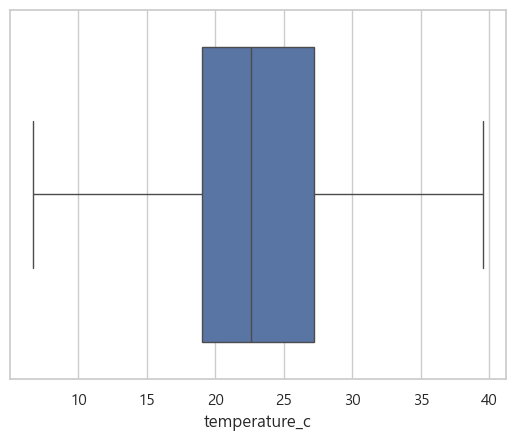

In [696]:
# 전처리 후 박스 플롯
sns.boxplot(x=df['temperature_c'])
plt.show()

### humidity_pct의 boxplot, IQR, 이상치 개수 구하기

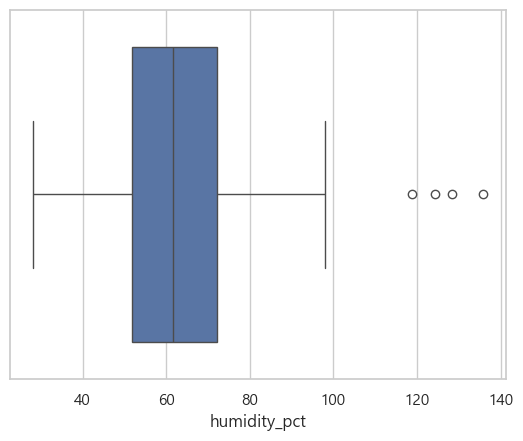

In [697]:
sns.boxplot(x=df['humidity_pct'])
plt.show()

In [698]:
# IQR 구하기
q1 = df['humidity_pct'].quantile(.25)
q3 = df['humidity_pct'].quantile(.75)
iqr = q3 - q1

q1, q3, iqr

(np.float64(51.75), np.float64(72.1), np.float64(20.349999999999994))

In [699]:
# 결측치 범위 및 개수 구하기
lower = q1 - (q1 * 1.5)
upper = q3 + (q3 * 1.5)
lower, upper

(np.float64(-25.875), np.float64(180.25))

In [700]:
error_count_hum = ((df['humidity_pct'] > upper) | (df['humidity_pct'] < lower)).sum()
error_count_hum

np.int64(0)

In [701]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


### 결측치 처리 - 현실 범위 경계값으로 보정
- 습도 100% 초과처럼 도메인 규칙을 위반한 값이므로 현실 범위 경계값(100)으로 보정한다.

In [702]:
# 100보다 큰 값을 모두 100으로 변경
df['humidity_pct'] =df['humidity_pct'].clip(0, 100)
df['humidity_pct']

0      77.0
1      74.6
2      56.3
3      77.3
4      46.3
       ... 
647    72.0
648    77.0
649    42.5
650    76.3
651    73.8
Name: humidity_pct, Length: 652, dtype: float64

In [703]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


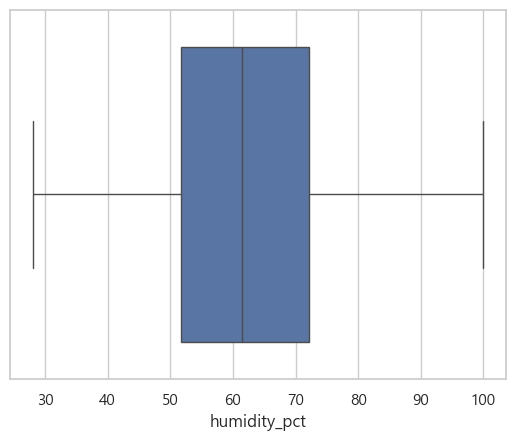

In [704]:
sns.boxplot(x=df['humidity_pct'])
plt.show()

### distance_km의 boxplot, IQR, 이상치 개수 구하기

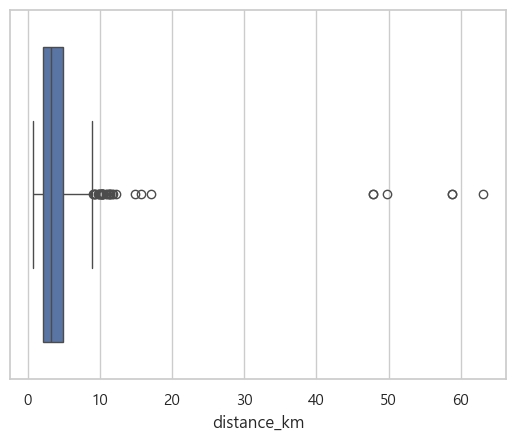

In [705]:
sns.boxplot(x=df['distance_km'])
plt.show()

In [706]:
# IQR 구하기
q1 = df['distance_km'].quantile(.25)
q3 = df['distance_km'].quantile(.75)

iqr = q3 - q1

q1, q3, iqr

(np.float64(2.18), np.float64(4.91), np.float64(2.73))

In [707]:
lower = q1 - (q1 * 1.5)
upper = q3 + (q3 * 1.5)

lower, upper

(np.float64(-1.0900000000000003), np.float64(12.275))

In [708]:
c_outlier = ((df['distance_km'] > upper) | (df['distance_km'] <lower)).sum()
c_outlier

np.int64(9)

### 결측치 처리 - 원본값 유지
- 특정 지역에 공유자전거 이용자들이 많은 경우 이동거리에서 이상치가 충분히 나올수 있으므로 원본값을 그대로 유지한다.

In [709]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


### ride_duration_min(최소 이용 시간)의 boxplot, IQR, 이상치 개수 구하기

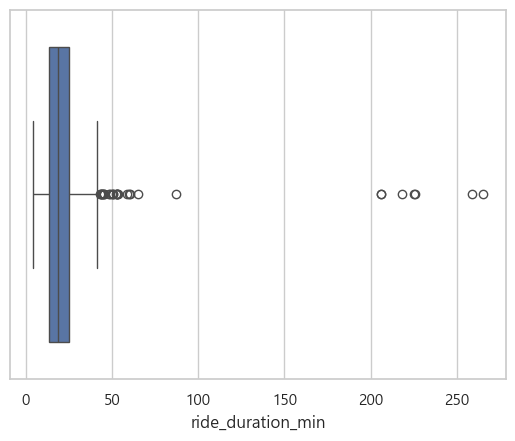

In [710]:
sns.boxplot(x=df['ride_duration_min'])
plt.show()

In [711]:
# IQR 구하기
q1 = df['ride_duration_min'].quantile(.25)
q3 = df['ride_duration_min'].quantile(.75)

iqr = q3 - q1

q1, q3, irq

(np.float64(13.5), np.float64(24.9), np.float64(8.225000000000001))

In [712]:
lower = q1 - (q1 * 1.5)
upper = q3 + (q3 * 1.5)

lower, upper

(np.float64(-6.75), np.float64(62.24999999999999))

In [713]:
c_outlier = ((df['ride_duration_min'] > upper) |(df['ride_duration_min'] < lower)).sum()
c_outlier

np.int64(9)

### 결측치 처리 - 원본값 유지
- 특정 공유자전거 이용자들이 많은 경우 이동거리와 마찬가지로  이용 최소 시간도 이상치가 충분히 나올수 있으므로 원본값을 그대로 유지한다.

In [714]:
df

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...
647,R0409,대학가,NaN,맑음,26.9,72.0,5.2,3.40,19.6,13.0,0
648,R0513,도심,월회원,흐림,14.1,77.0,2.8,1.66,16.9,28.0,1
649,R0602,도심,연회원,맑음,25.3,42.5,1.9,5.29,24.9,3.0,0
650,R0064,대학가,일일권,흐림,29.4,76.3,1.6,1.44,205.7,37.0,0


## 문제 4. 파생변수, 인코딩, 스케일링

- 1. 아래 파생변수 중 2개 이상을 생성하세요.
    - `avg_speed_kmh = distance_km / (ride_duration_min / 60)`
    - `bad_weather = weather`가 비이면 1, 아니면 0
    - `old_bike = bike_age_months`가 전체 중앙값보다 크면 1, 아니면 0
- 2. 0으로 나누는 상황이나 비정상적인 속도가 생기지 않는지 확인하세요.
- 3. 순서가 없는 다중 범주형 컬럼은 원-핫 인코딩하세요.
- 4. `late_return`과 식별자는 스케일링 대상에서 제외하고, 선택한 연속형 컬럼에 `StandardScaler`를 적용하세요.
- 5. 인코딩 전후 데이터의 `shape`를 비교하고 최종 데이터를 `A_공유자전거_cleaned.csv`로 저장하세요.

In [722]:
df_dup["avg_speed_kmh"] = df_dup["distance_km"].div(df_dup["ride_duration_min"].div(60))
df_dup["avg_speed_kmh"].describe()

count    644.000000
mean      12.866638
std       22.046862
min        0.420029
25%        9.267358
50%       11.093866
75%       12.867059
max      360.800000
Name: avg_speed_kmh, dtype: float64

### `bad_weather = weather`가 비이면 1, 아니면 0

In [723]:
df_dup['bad_weather'] = df_dup['weather'].eq('비')
df_dup['bad_weather'] 

0       True
1      False
2      False
3      False
4      False
       ...  
639     True
640     True
641    False
642    False
643    False
Name: bad_weather, Length: 644, dtype: bool

In [727]:
df_dup['bad_weather']=df_dup['bad_weather'].map({'비': 1}).fillna(0).astype(int)
df_dup['bad_weather']

0      0
1      0
2      0
3      0
4      0
      ..
639    0
640    0
641    0
642    0
643    0
Name: bad_weather, Length: 644, dtype: int64

In [733]:
df_dup['old_bike'] = (df_dup['bike_age_months'] > df_dup['bike_age_months'].median()).astype(int)

df_dup['old_bike']

0      1
1      1
2      1
3      0
4      1
      ..
639    0
640    1
641    0
642    1
643    0
Name: old_bike, Length: 644, dtype: int64

In [734]:
df_dup


,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return,avg_speed_kmh,bad_weather,old_bike
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,18.6,28.0,0,13.258065,0,1
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0,7.363636,0,1
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0,7.706897,0,1
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0,14.683636,0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0,10.594286,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
639,R0640,주거,월회원,비,30.6,77.7,4.8,1.52,18.6,1.0,0,4.903226,0,0
640,R0641,대학가,일일권,비,25.8,69.4,4.6,6.19,35.4,23.0,0,10.491525,0,1
641,R0642,대학가,연회원,흐림,22.4,80.8,5.5,1.53,8.6,22.0,0,10.674419,0,0
642,R0643,주거,월회원,맑음,31.6,64.0,3.4,3.08,17.9,27.0,0,10.324022,0,1
